<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Image-Detection/blob/main/YOLOv11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sun Sep 20 01:28:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME=os.getcwd()
print(HOME)

/content


## Install YOLO11 wia ultralytics

In [ ]:
!pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


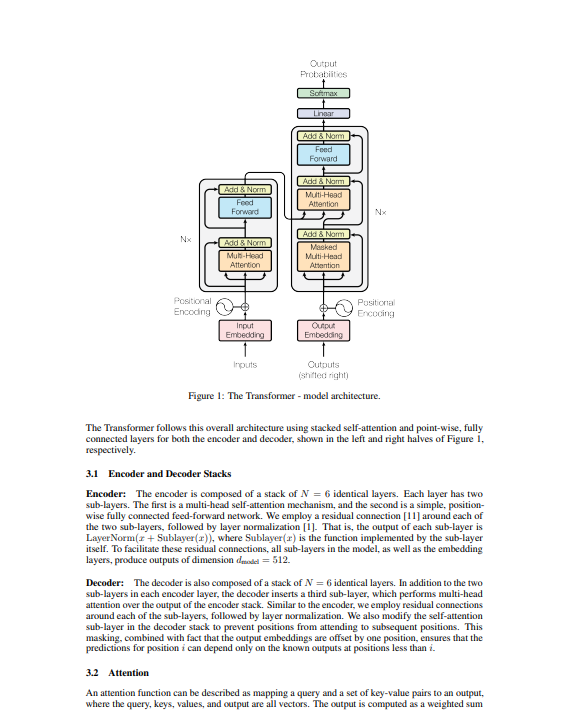

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(filename=f'{HOME}/Screenshot 2026-09-20 073437.png')

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model= YOLO('yolo11n.pt')
image=Image.open('/content/Screenshot 2026-09-20 073437.png')
result=model.predict(image, conf=0.25)[0]


0: 640x512 (no detections), 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 512)


In [ ]:
result.boxes.xyxy

tensor([], device='cuda:0', size=(0, 4))

In [ ]:
result.boxes.conf

tensor([], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([], device='cuda:0')

In [ ]:
import supervision as sv
detection = sv.Detections.from_ultralytics(result)

In [ ]:
detection

Detections(xyxy=array([], shape=(0, 4), dtype=float32), mask=None, confidence=array([], dtype=float32), class_id=array([], dtype=int64), tracker_id=None, data={'class_name': array([], dtype=float64)}, metadata={})

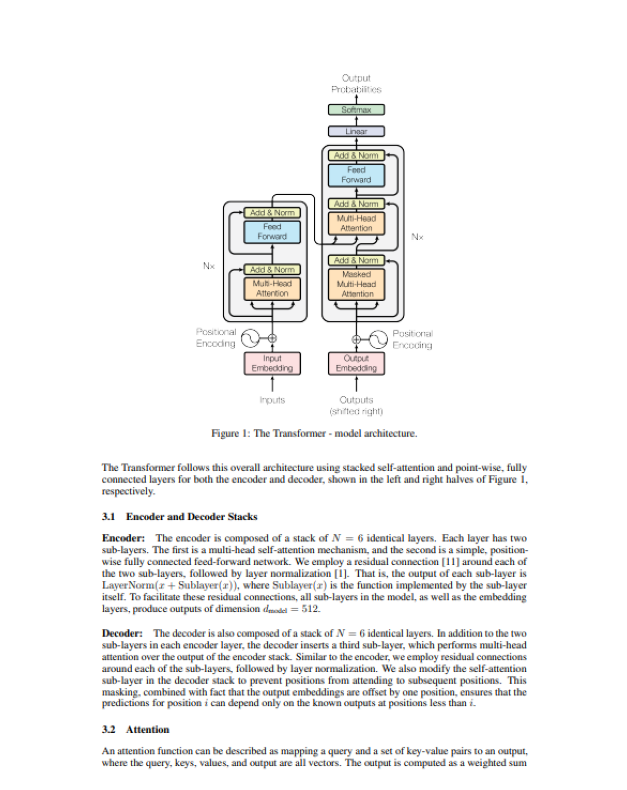

In [ ]:
box_annotator=sv.BoxAnnotator()
label_annotator=sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image=image.copy()
annotated_image=box_annotator.annotate(annotated_image,detections=detection)
annotated_image=label_annotator.annotate(annotated_image,detections=detection)

sv.plot_image(annotated_image,size=(10,10))

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model= YOLO('yolo11n.pt')
image=Image.open('/content/istockphoto-1252455620-612x612.jpg')
result=model.predict(image, conf=0.25)[0]


0: 448x640 1 dog, 7.5ms
Speed: 1.4ms preprocess, 7.5ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
import supervision as sv
detection = sv.Detections.from_ultralytics(result)

In [ ]:
detection

Detections(xyxy=array([[     262.94,      124.91,      388.24,      333.21]], dtype=float32), mask=None, confidence=array([    0.87498], dtype=float32), class_id=array([16]), tracker_id=None, data={'class_name': array(['dog'], dtype='<U3')}, metadata={})

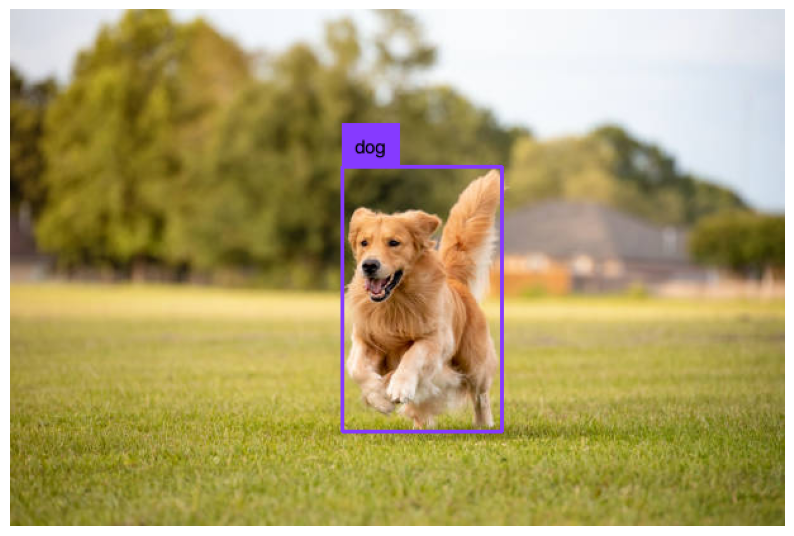

In [ ]:
box_annotator=sv.BoxAnnotator()
label_annotator=sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image=image.copy()
annotated_image=box_annotator.annotate(annotated_image,detections=detection)
annotated_image=label_annotator.annotate(annotated_image,detections=detection)

sv.plot_image(annotated_image,size=(10,10))

## fine tune yolov11 on custom dataset

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata

from roboflow import Roboflow
ROBOFLOW_API_KEY = Roboflow(api_key='ROBOFLOW_API_KEY')
project = rf.workspace("tauhid-topu").project("tft-id-adcwr-rdfws")
version = project.version(1)
dataset = version.download("yolov11")

mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...


In [ ]:
dataset.location

'/content/datasets/TFT-ID-1'

In [ ]:
%cd {HOME}

/content


In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=30 imgsz=640 plots=True

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/TFT-ID-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, o

In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=70 imgsz=640 plots=True

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/TFT-ID-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=None, opset=None, o

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml			 confusion_matrix.png  train_batch2.jpg
BoxF1_curve.png			 labels.jpg	       val_batch0_labels.jpg
BoxP_curve.png			 results.csv	       val_batch0_pred.jpg
BoxPR_curve.png			 results.png	       weights
BoxR_curve.png			 train_batch0.jpg
confusion_matrix_normalized.png  train_batch1.jpg


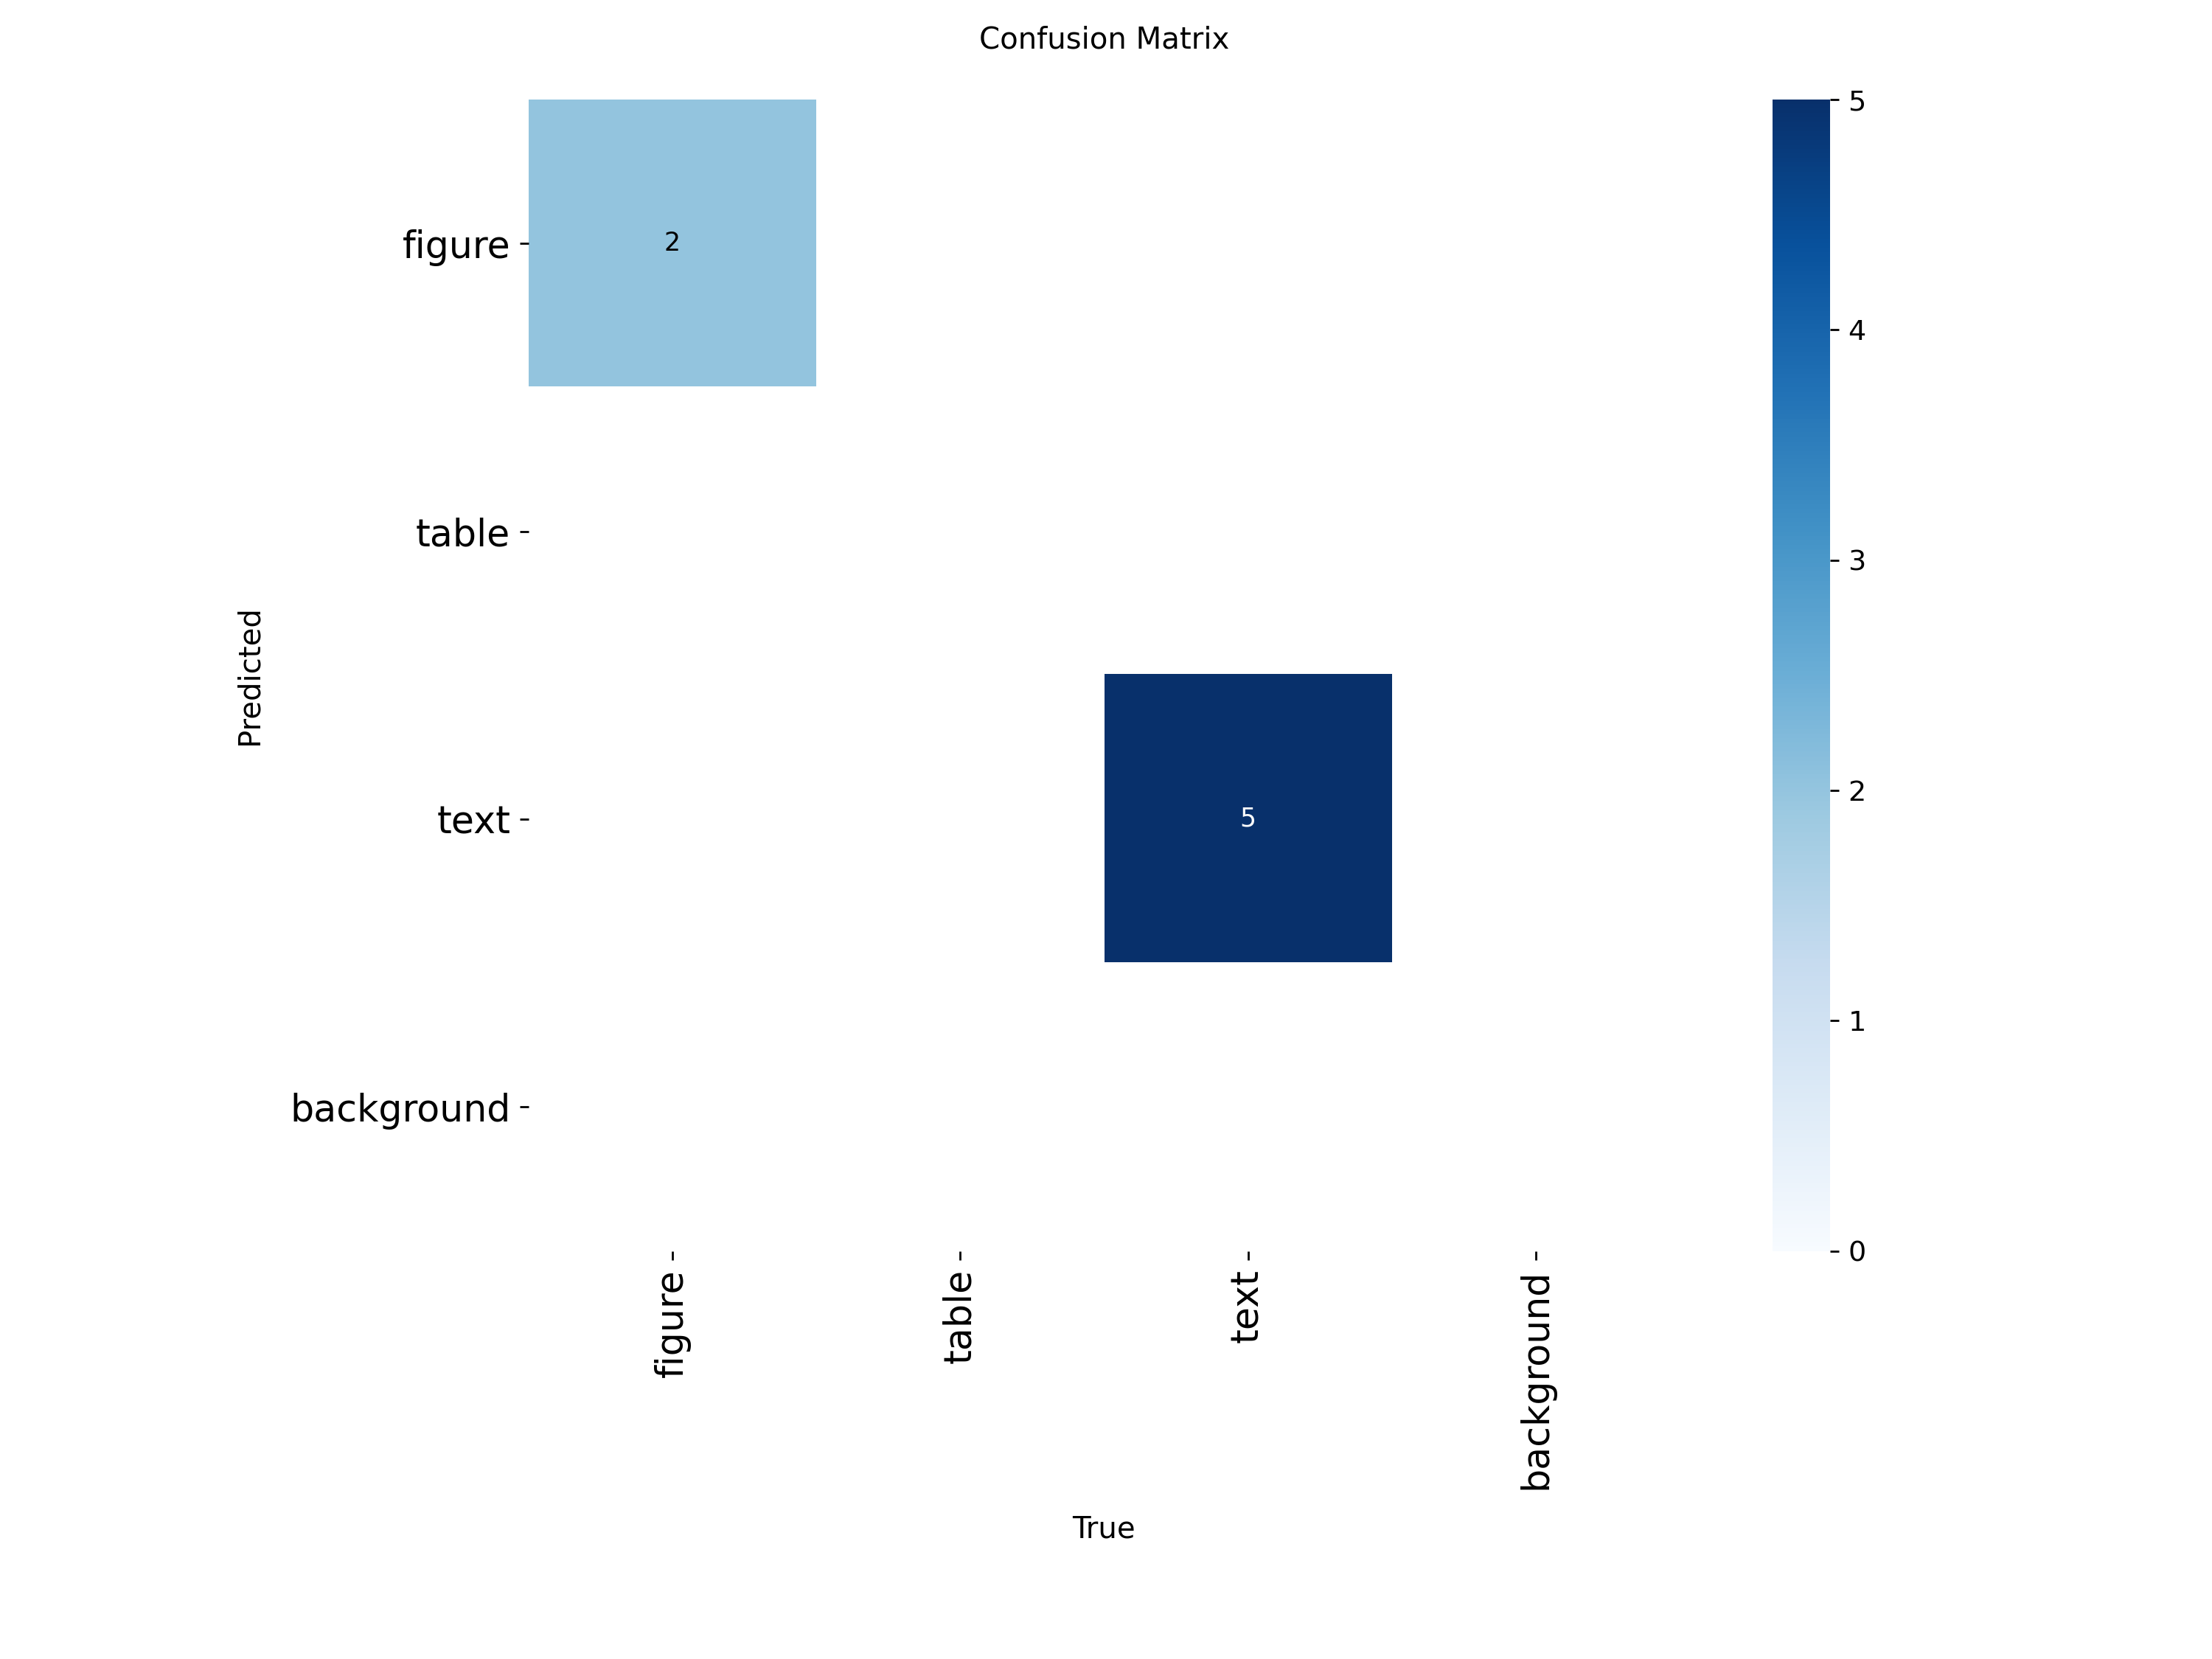

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(filename=f'{HOME}/runs/detect/train-3/confusion_matrix.png',width=600)

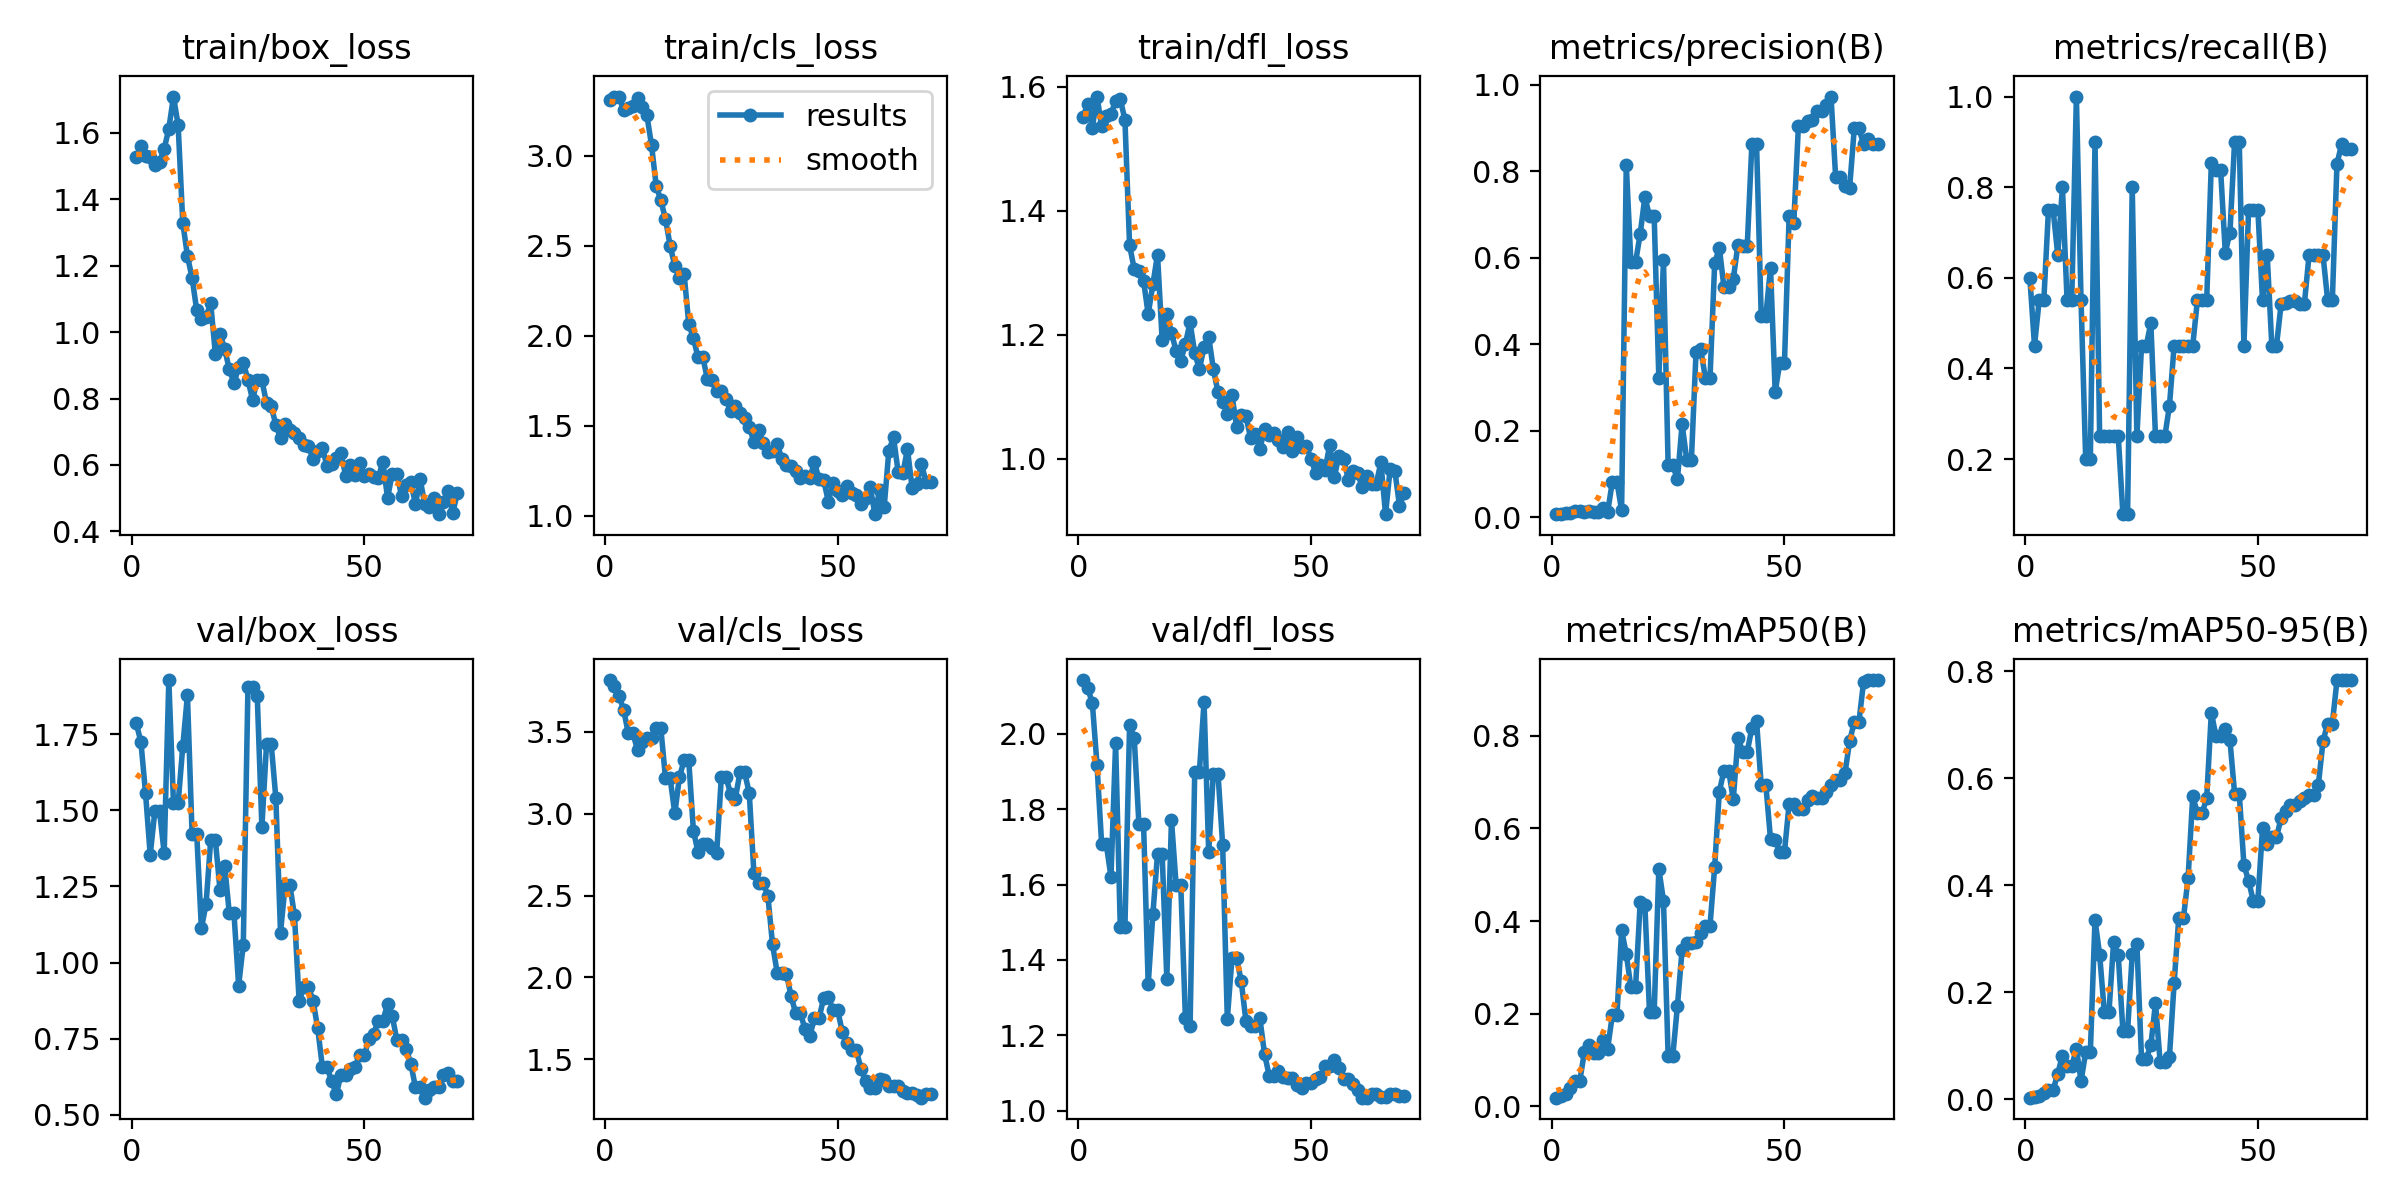

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(filename=f'{HOME}/runs/detect/train-3/results.png',width=600)

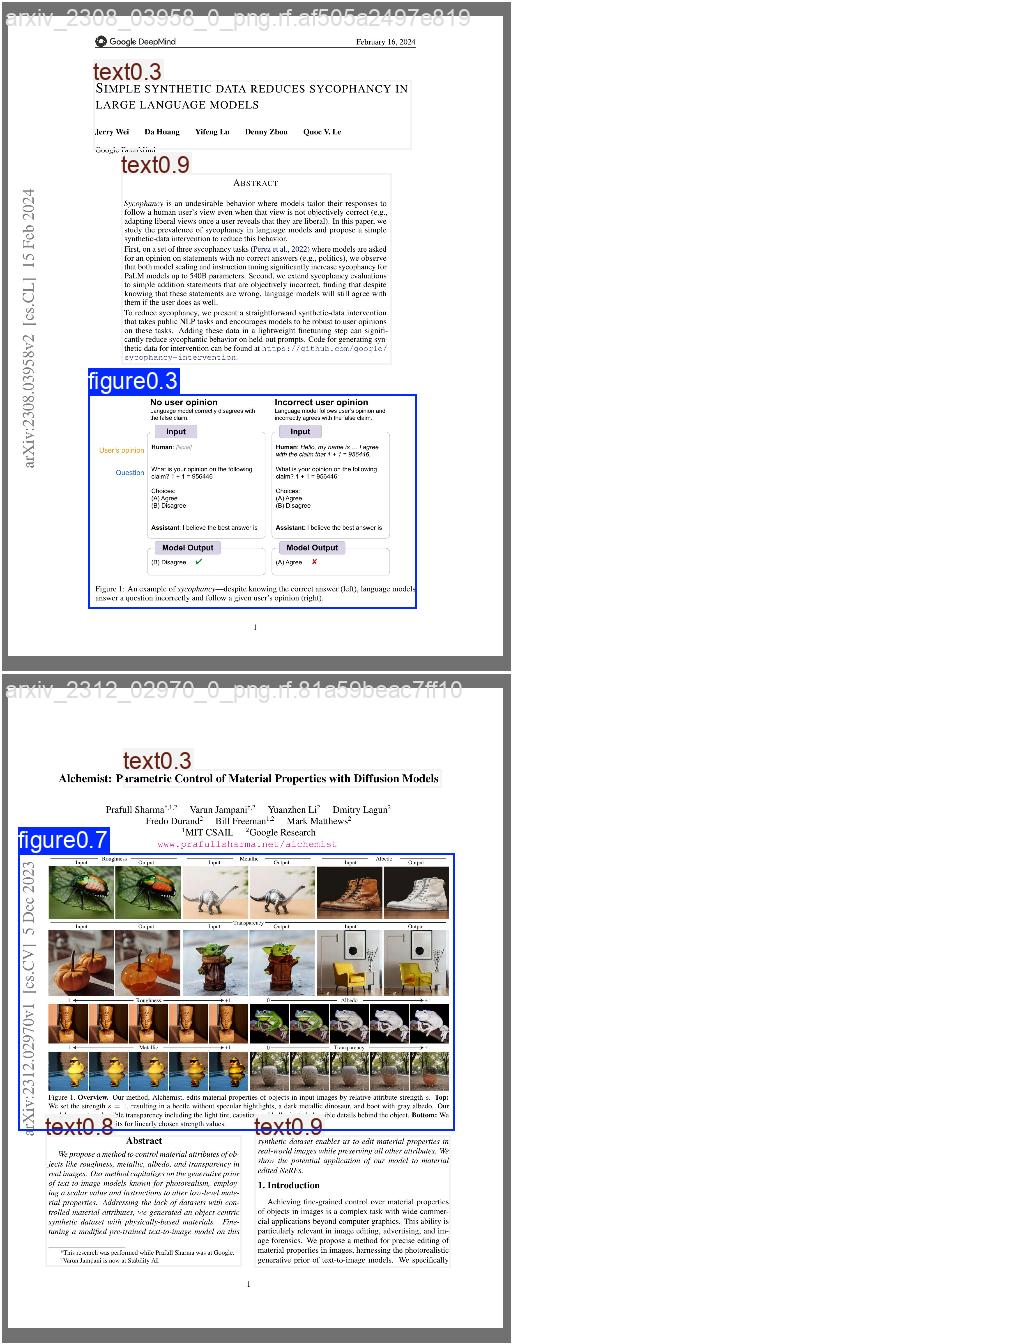

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(filename=f'{HOME}/runs/detect/train-3/val_batch0_pred.jpg',width=600)

In [ ]:
!yolo task=detect mode=val \
  model={HOME}/runs/detect/train-3/weights/best.pt \
  data={dataset.location}/data.yaml \
  epochs=70 imgsz=640 plots=True

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1985.6±20.9 MB/s, size: 397.8 KB)
val: Scanning /content/datasets/TFT-ID-1/valid/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 322.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.3it/s 0.2s
                   all          2          7      0.877      0.896       0.92      0.784
                figure          2          2          1      0.992      0.995       0.92
                  text          2          5      0.755        0.8      0.846      0.647
Speed: 0.4ms preprocess, 27.4ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!yolo task=detect mode=predict \
  model={HOME}/runs/detect/train-3/weights/best.pt \
  conf=0.50 \
  source={dataset.location}/test/images save=True

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs

image 1/4 /content/datasets/TFT-ID-1/test/images/arxiv_2305_04966_0_png.rf.085abb804c7d4809207d4588716182be.jpg: 640x512 1 figure, 2 texts, 7.7ms
image 2/4 /content/datasets/TFT-ID-1/test/images/arxiv_2312_13285_1_png.rf.8ac8ee6f4507bdbd980cba52b232ea20.jpg: 640x512 4 texts, 8.2ms
image 3/4 /content/datasets/TFT-ID-1/test/images/arxiv_2403_05812_6_png.rf.431365316fd9858066eb329d3138a65c.jpg: 640x480 1 figure, 1 text, 48.9ms
image 4/4 /content/datasets/TFT-ID-1/test/images/arxiv_2404_05961_0_png.rf.9669d4cddc6fe130d0d7c79ced6cc78f.jpg: 640x512 3 texts, 8.4ms
Speed: 10.3ms preprocess, 18.3ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


Showing results from: /content/runs/detect/predict/


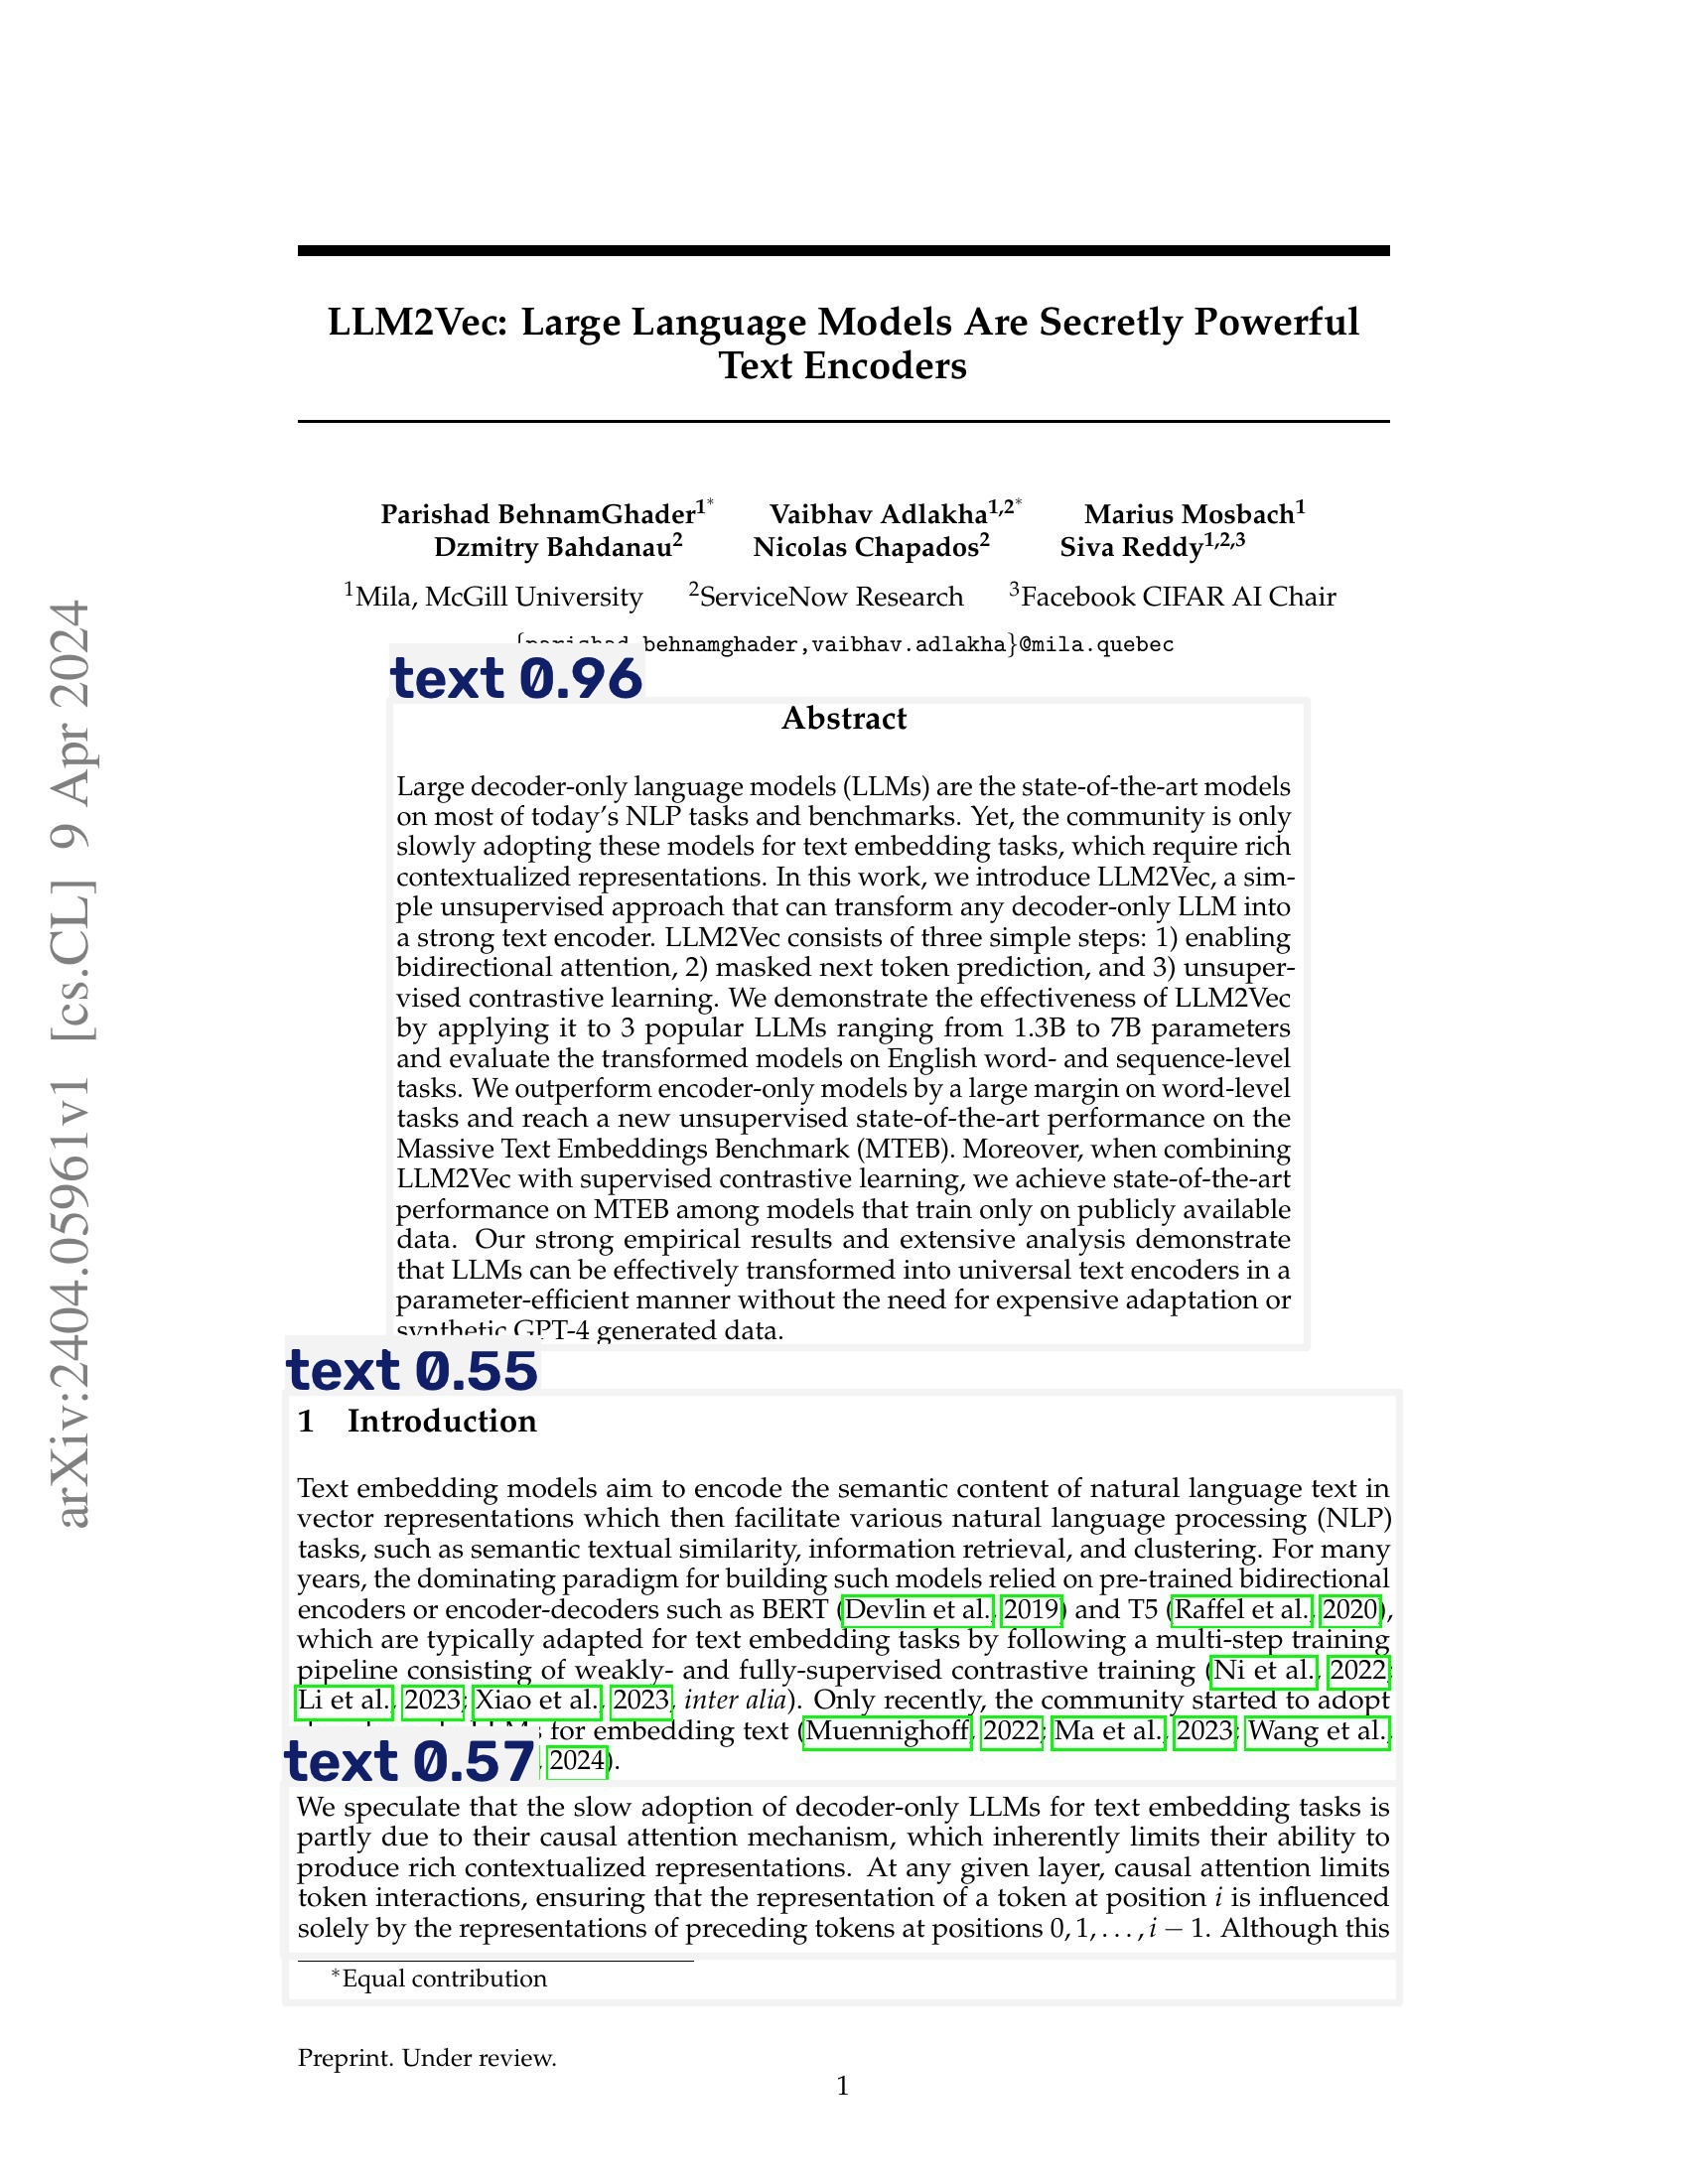

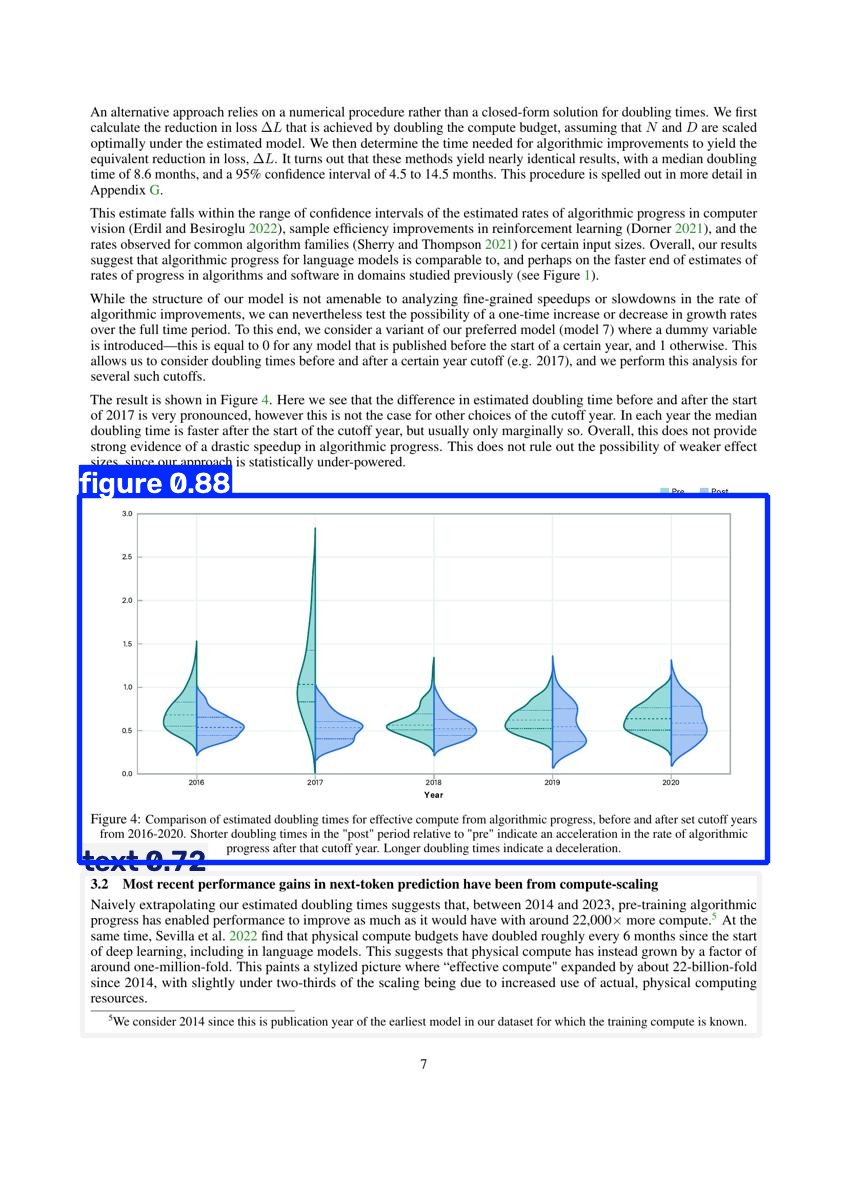

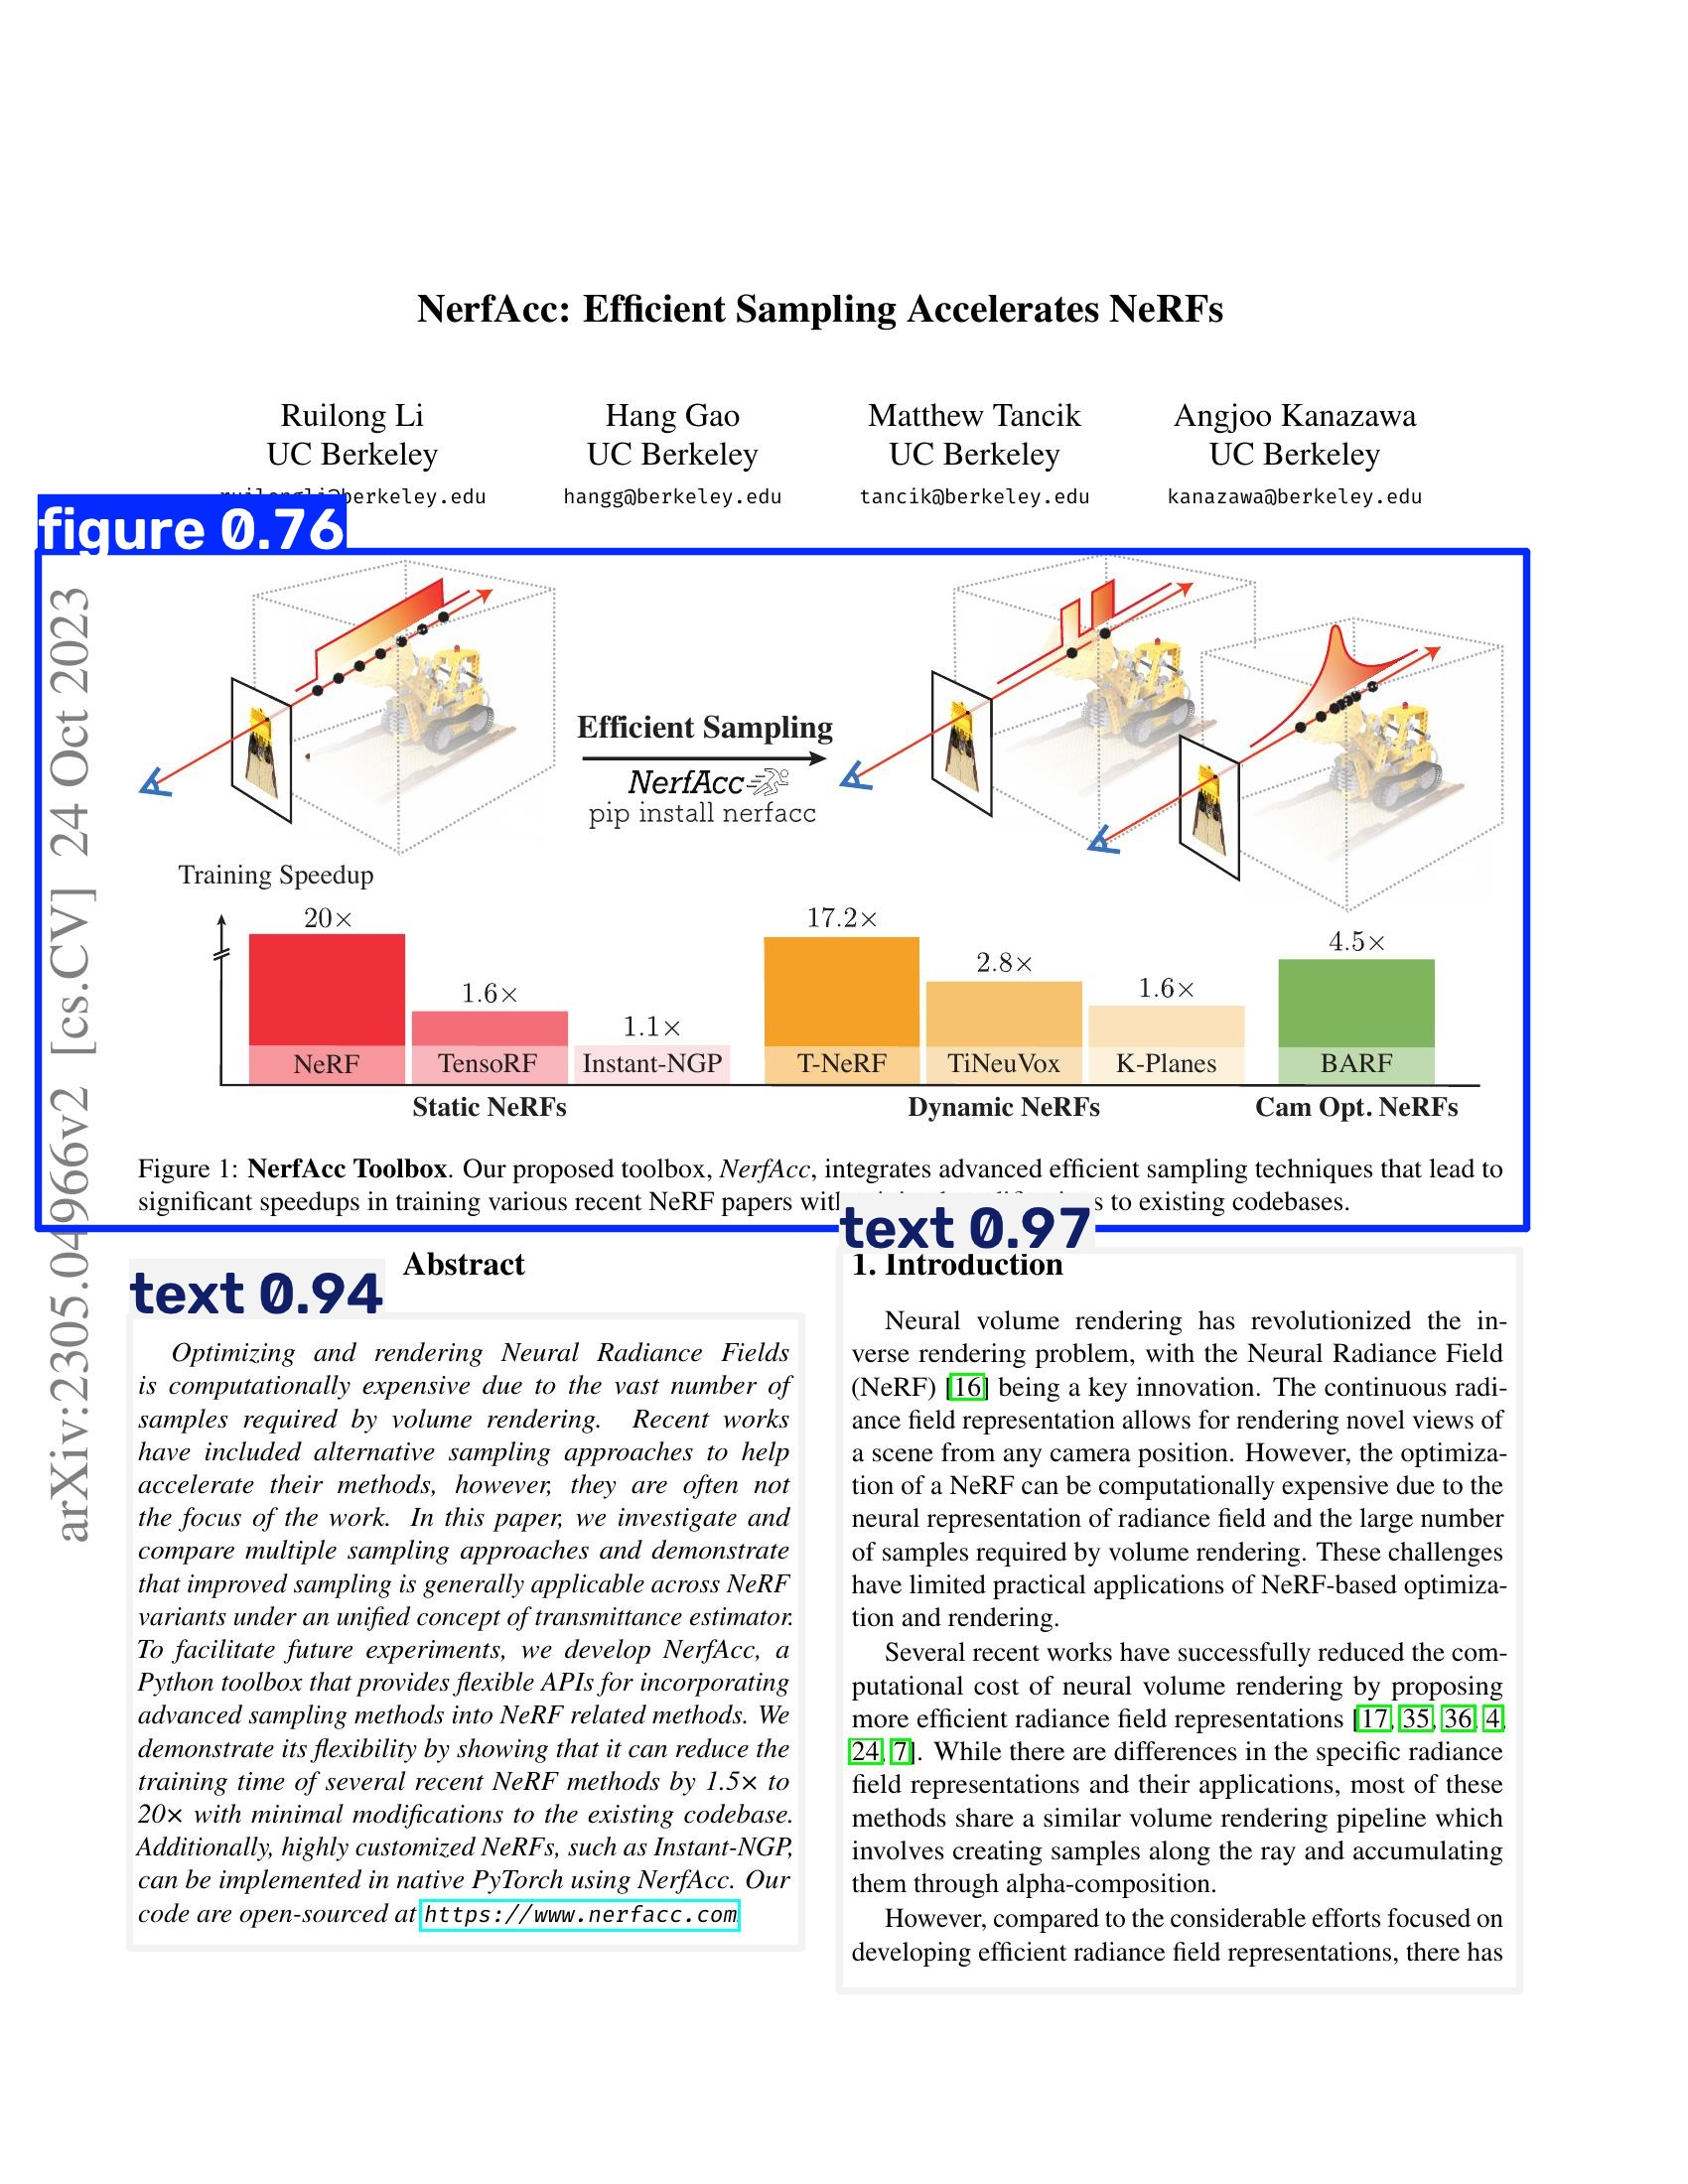

In [ ]:
import glob, os
from IPython.display import Image as IPyImage, display

# Accept both spellings and pick the newest match
folders = glob.glob('/content/runs/detect/predict*/') + glob.glob('/content/runs/detect/predice*/')

if not folders:
    print("No prediction folders found. Did the predict cell run successfully?")
    print("Contents of /content/runs/detect/:", os.listdir('/content/runs/detect') if os.path.exists('/content/runs/detect') else "path missing")
else:
    latest_folder = max(folders, key=os.path.getmtime)
    print("Showing results from:", latest_folder)
    imgs = glob.glob(f'{latest_folder}/*.jpg')
    if not imgs:
        print("Folder exists but contains no .jpg files.")
    for img in imgs[:3]:
        display(IPyImage(filename=img, width=600))
        print('\n')

## Load the model in new variable

In [ ]:
from ultralytics import YOLO
model_loaded=YOLO('/content/runs/detect/train-3/weights/best.pt')

## Inference

Running inference on arxiv_2312_13285_1_png.rf.8ac8ee6f4507bdbd980cba52b232ea20.jpg

0: 640x512 5 texts, 7.4ms
Speed: 3.3ms preprocess, 7.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)


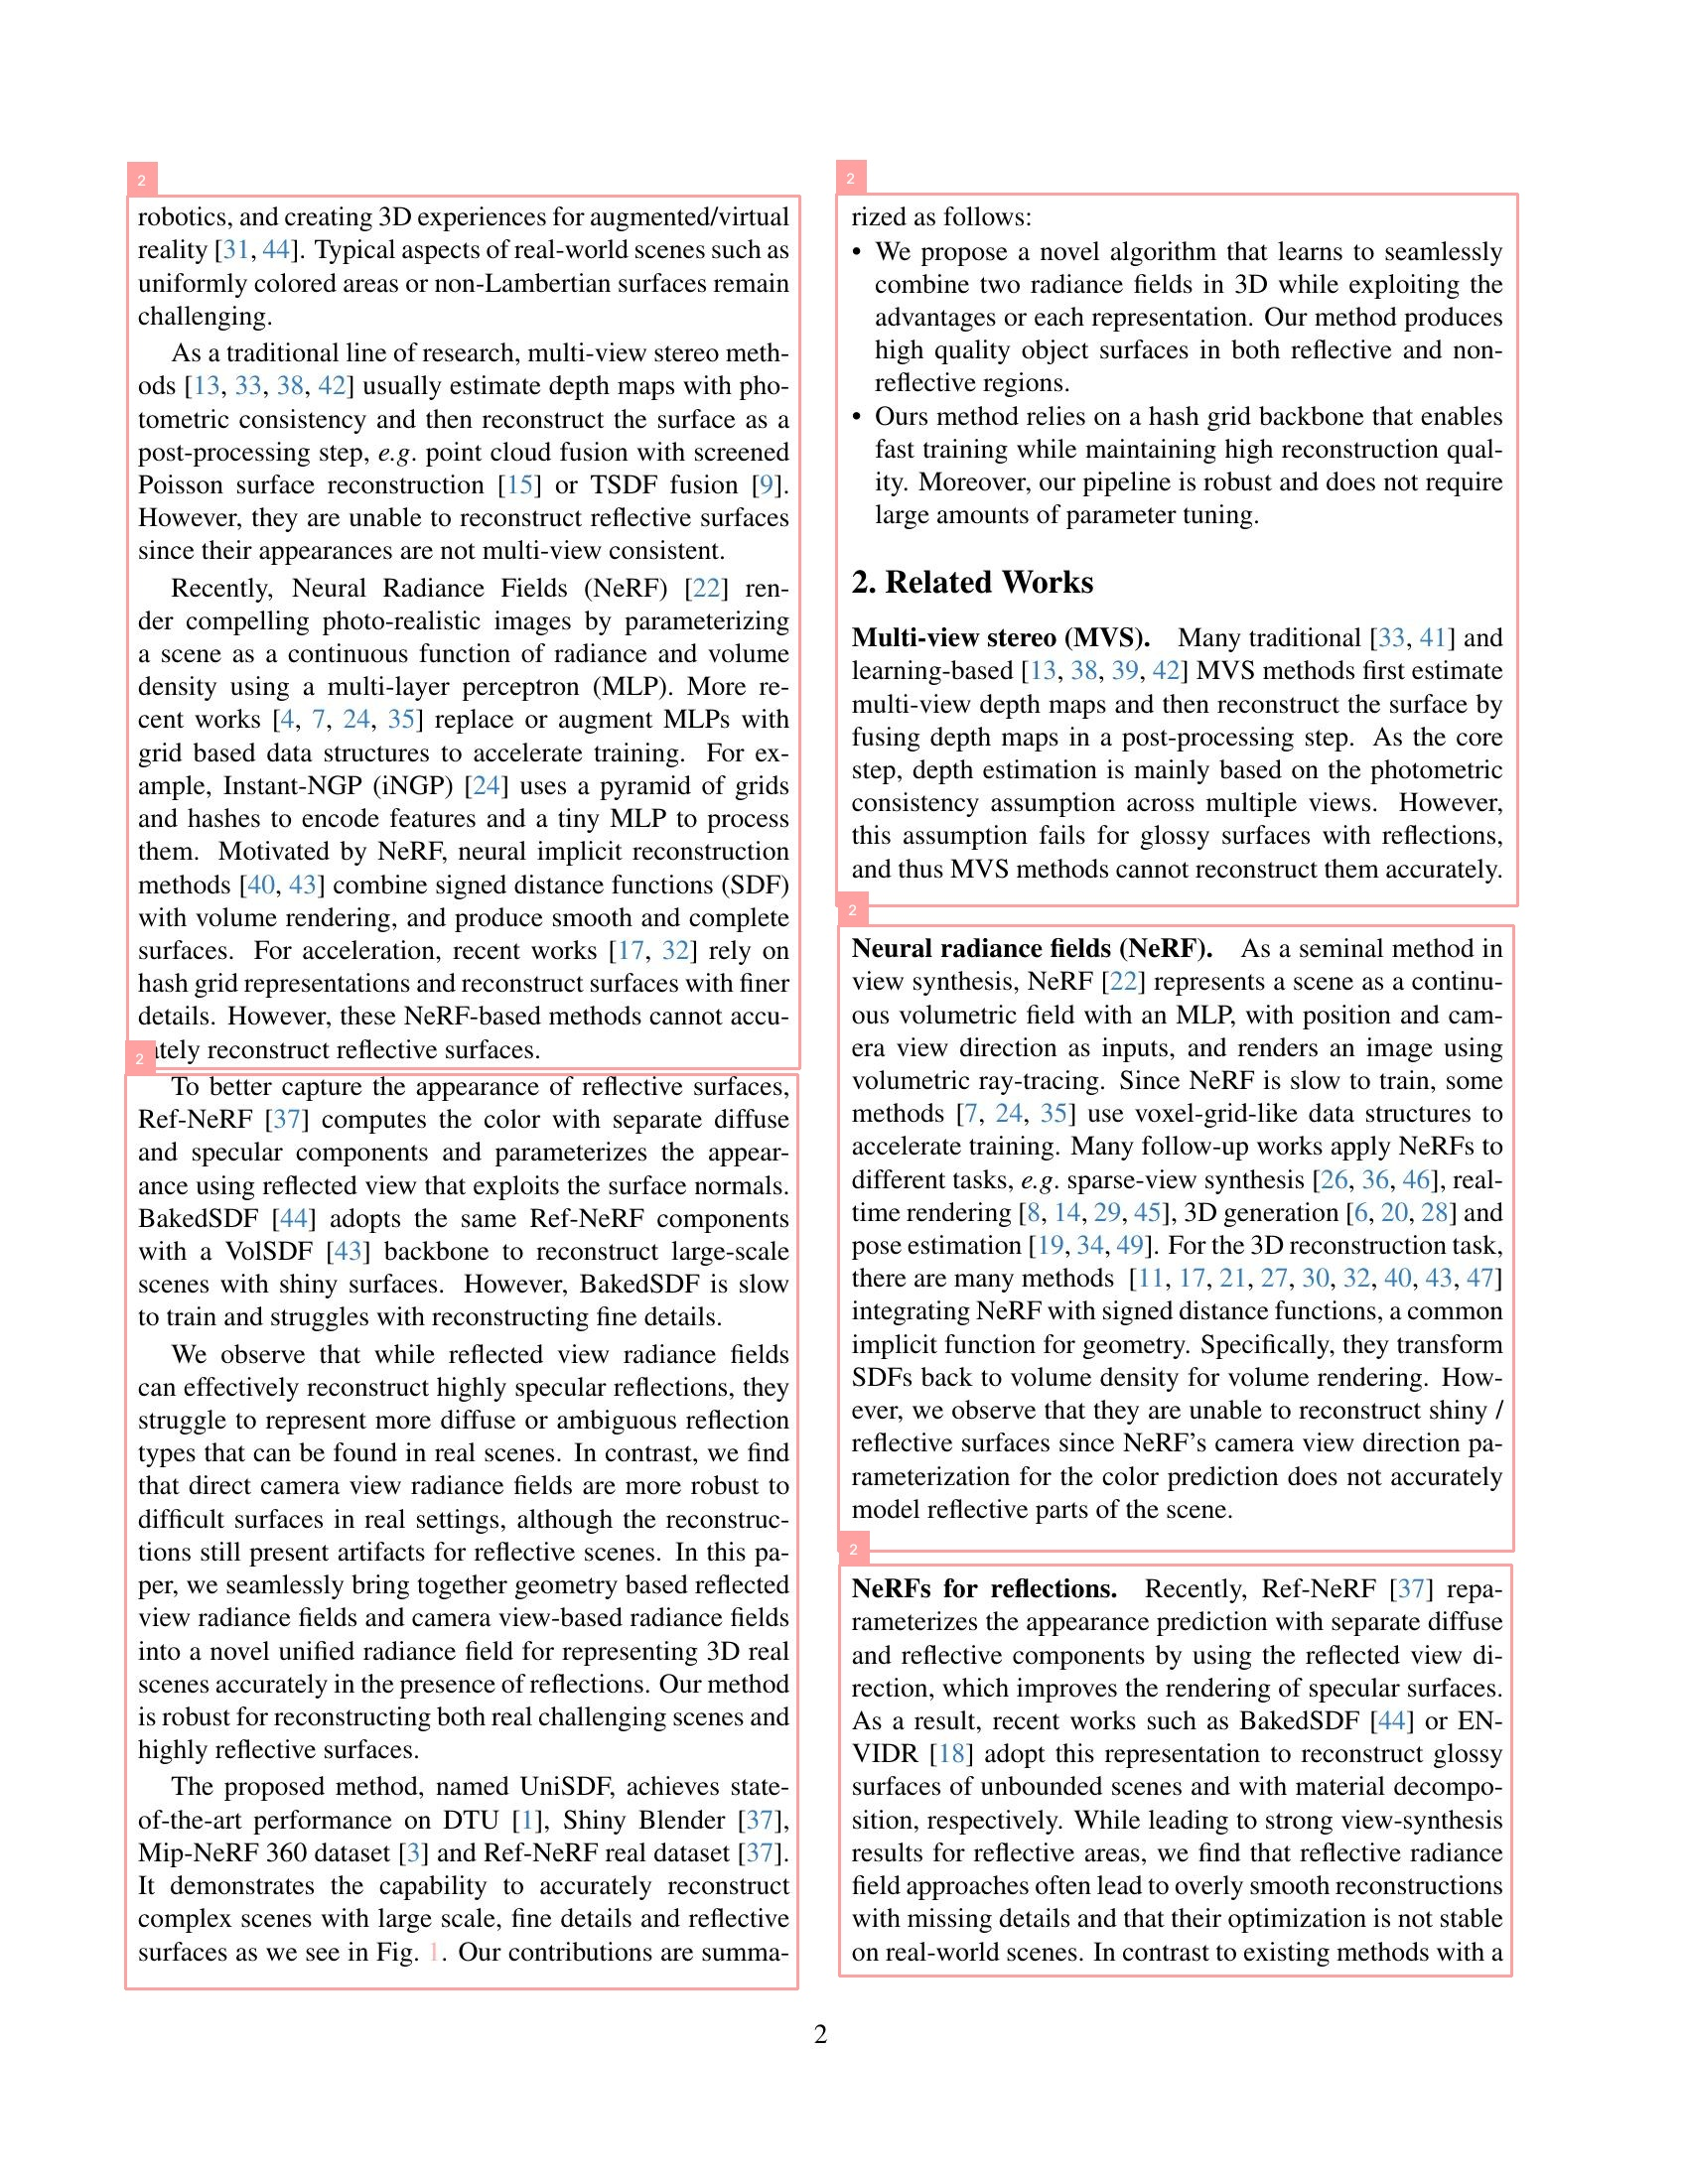

Running inference on arxiv_2305_04966_0_png.rf.085abb804c7d4809207d4588716182be.jpg

0: 640x512 1 figure, 2 texts, 12.5ms
Speed: 3.3ms preprocess, 12.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)


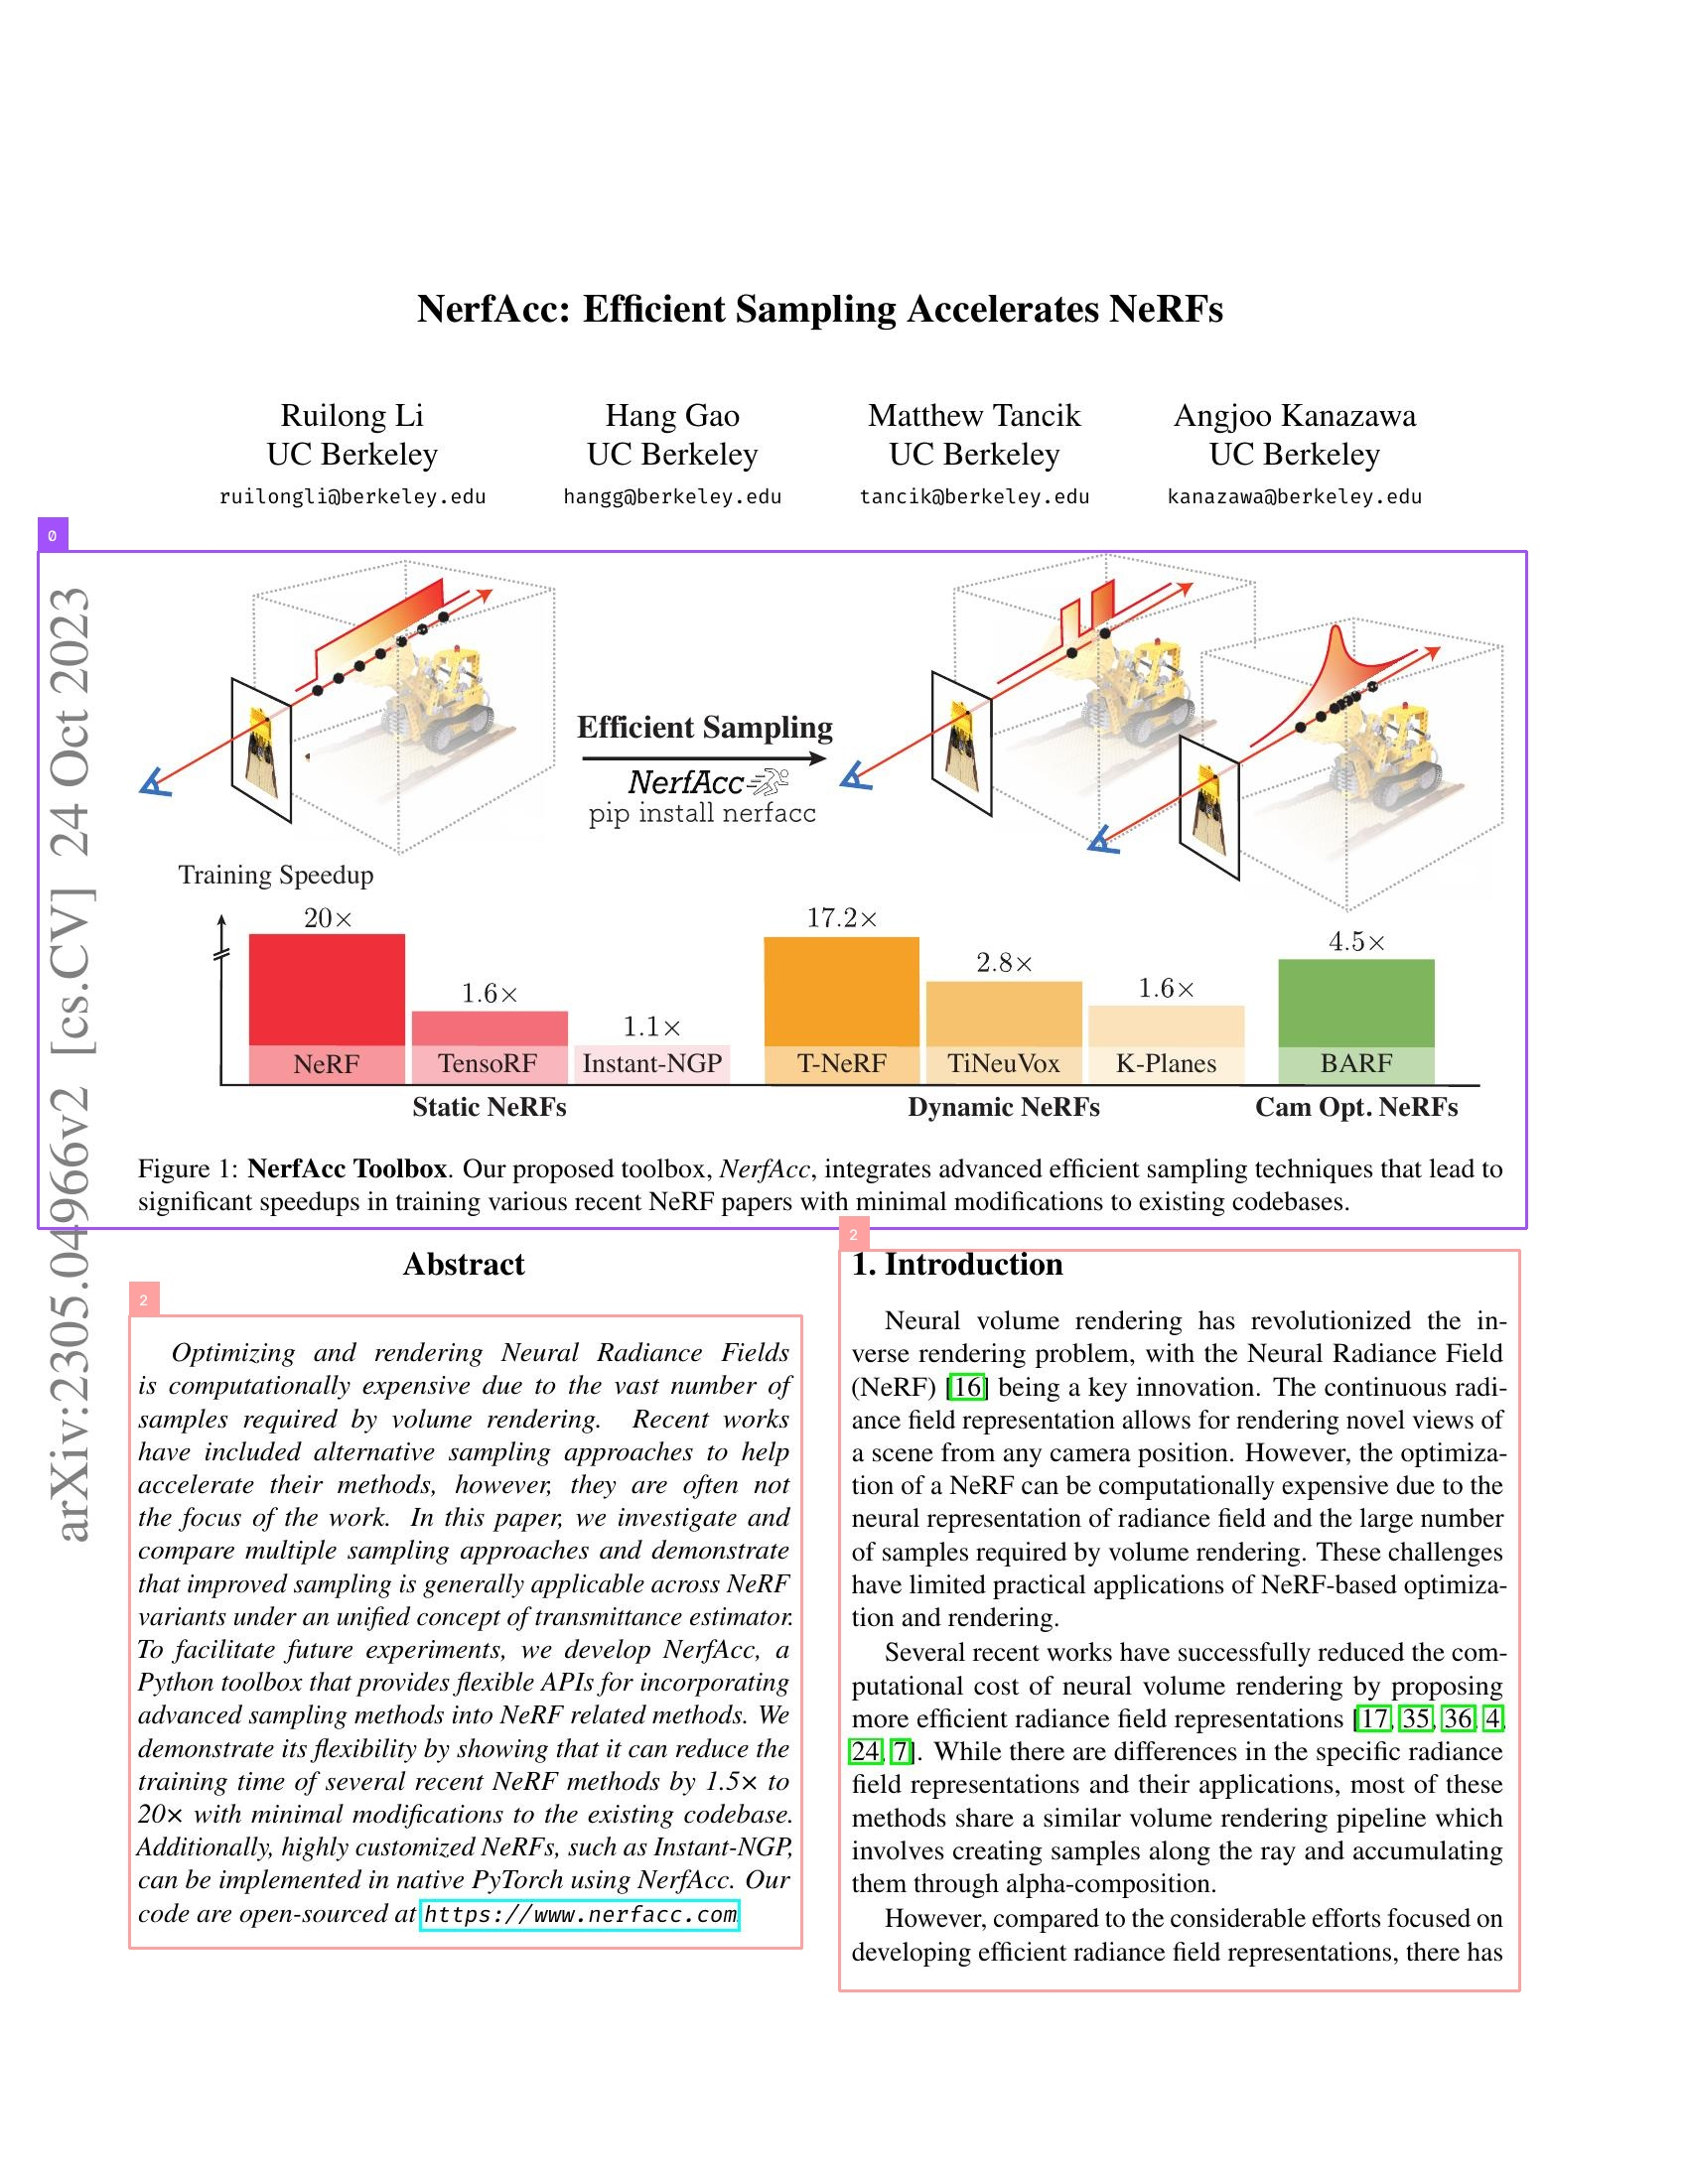

Running inference on arxiv_2404_05961_0_png.rf.9669d4cddc6fe130d0d7c79ced6cc78f.jpg

0: 640x512 4 texts, 12.9ms
Speed: 3.5ms preprocess, 12.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 512)


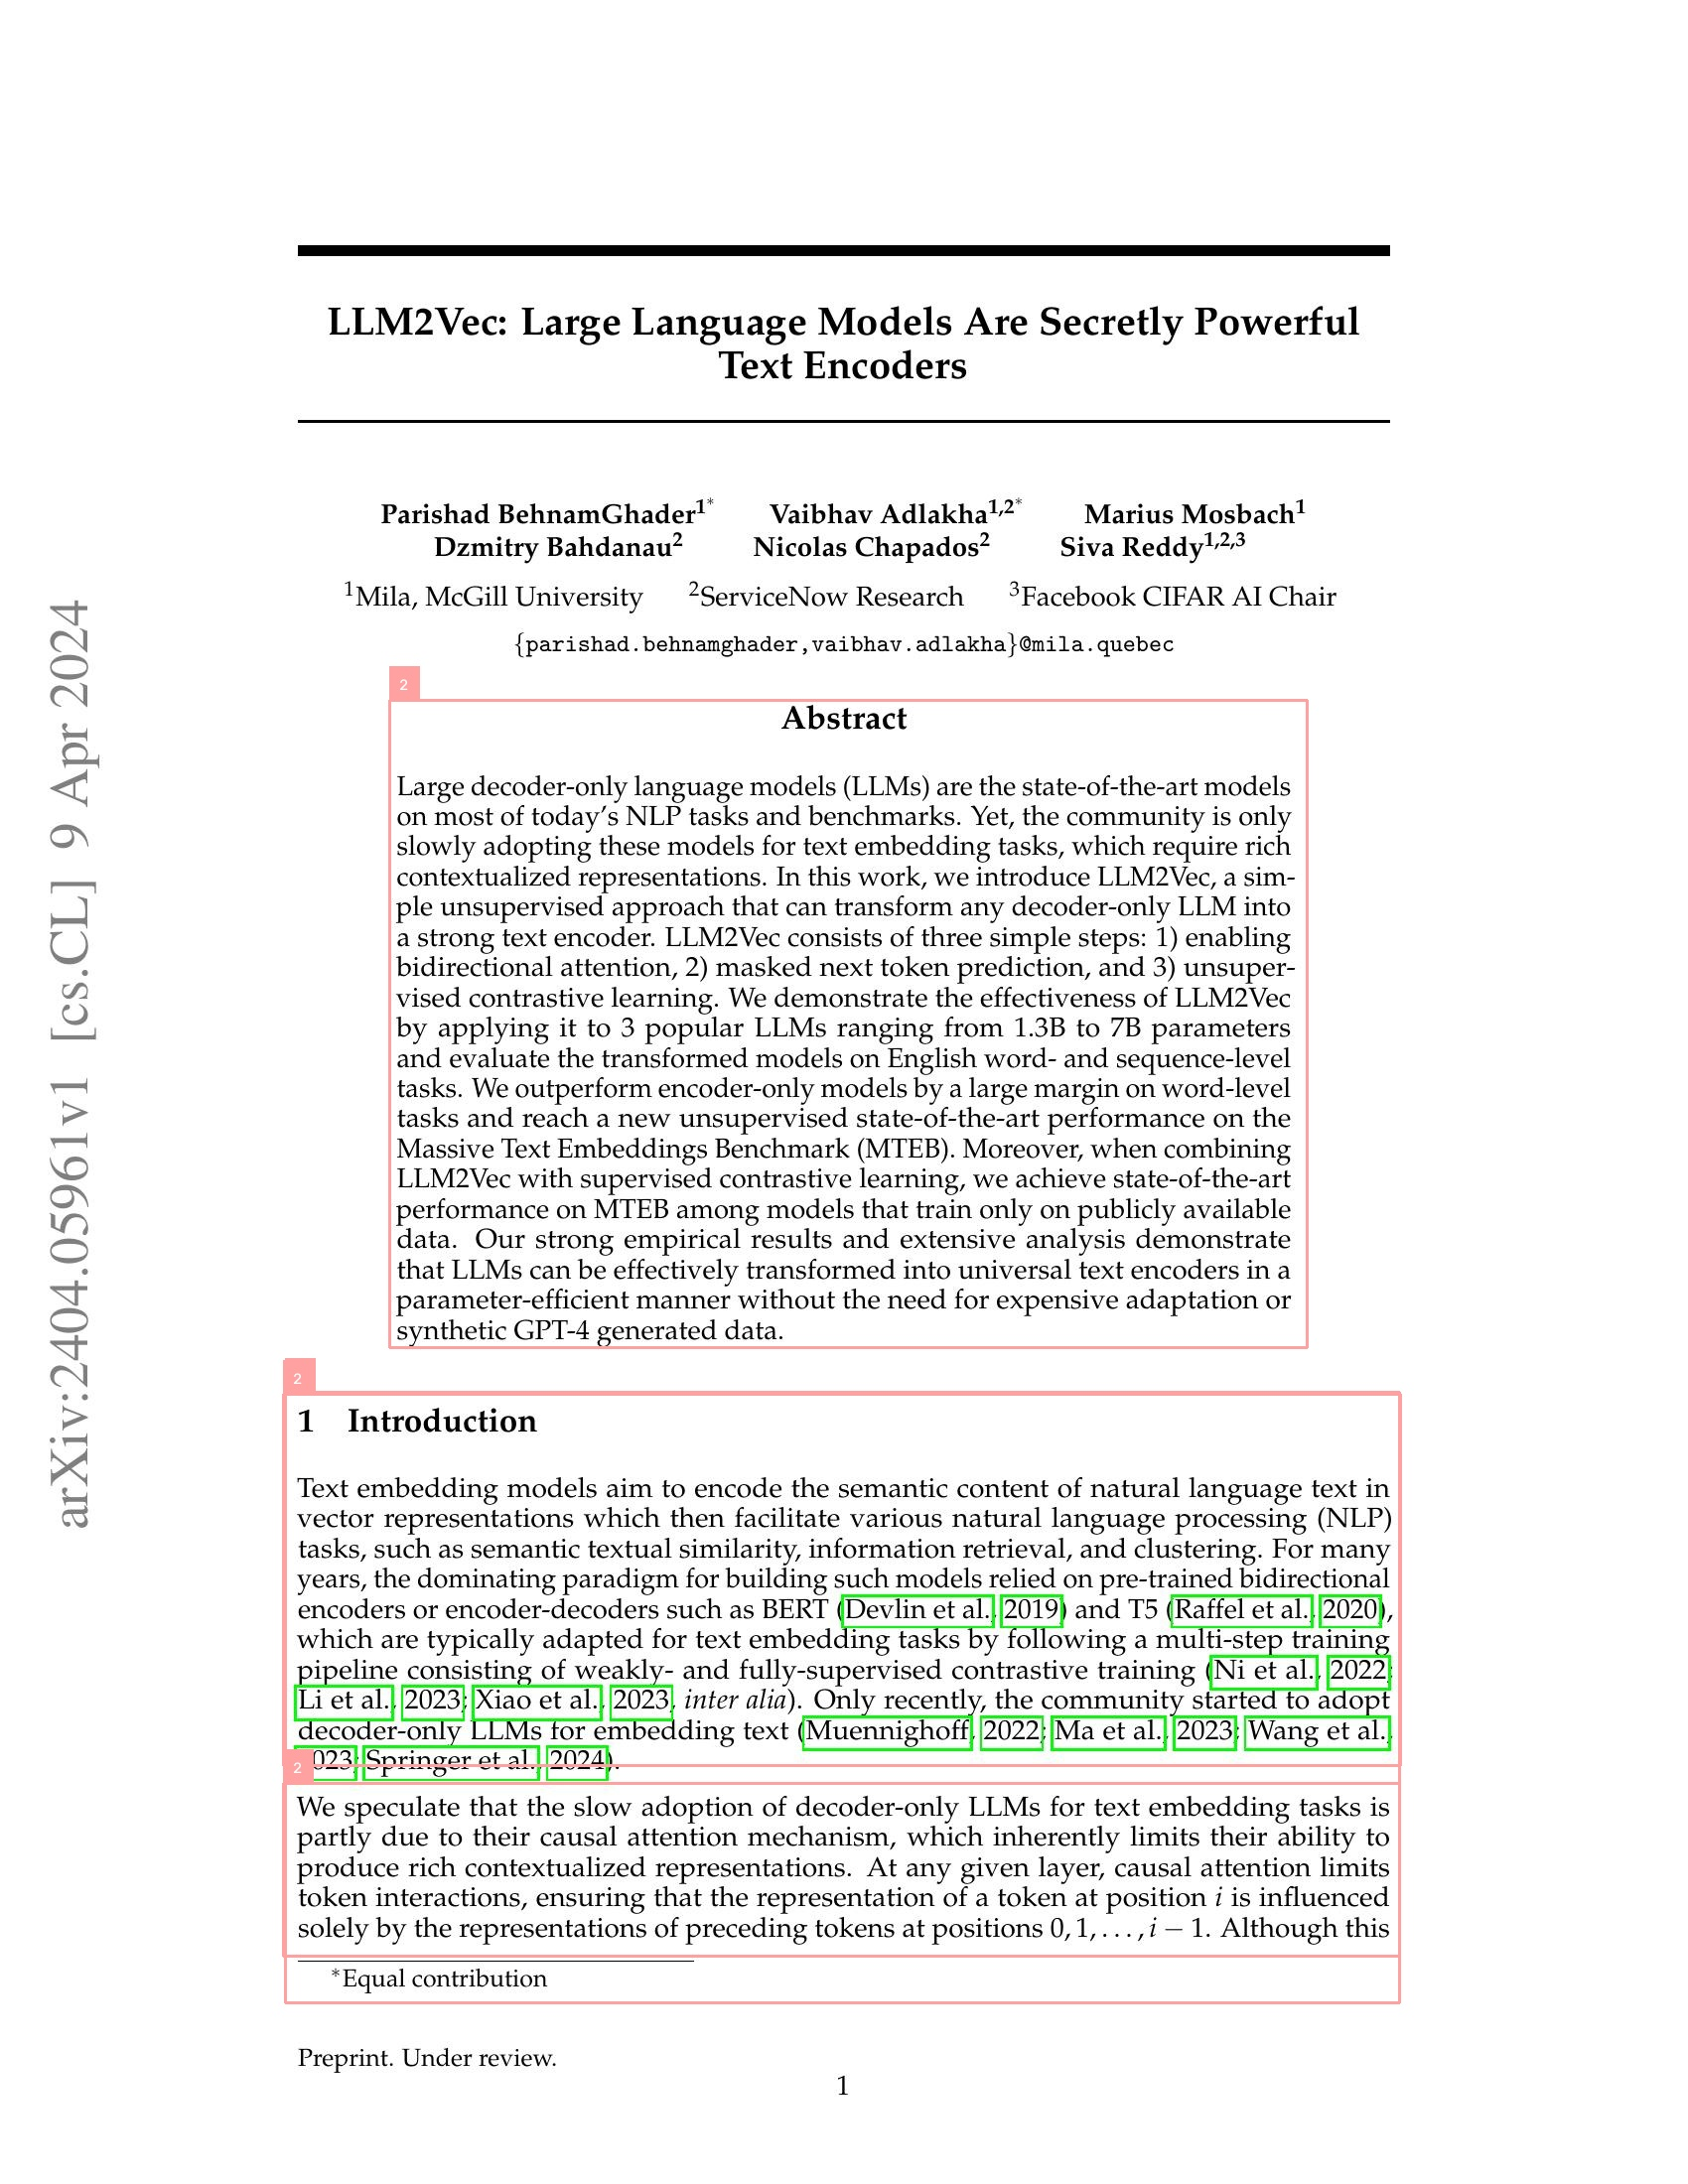

Running inference on arxiv_2403_05812_6_png.rf.431365316fd9858066eb329d3138a65c.jpg

0: 640x480 1 figure, 2 texts, 80.6ms
Speed: 2.9ms preprocess, 80.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)


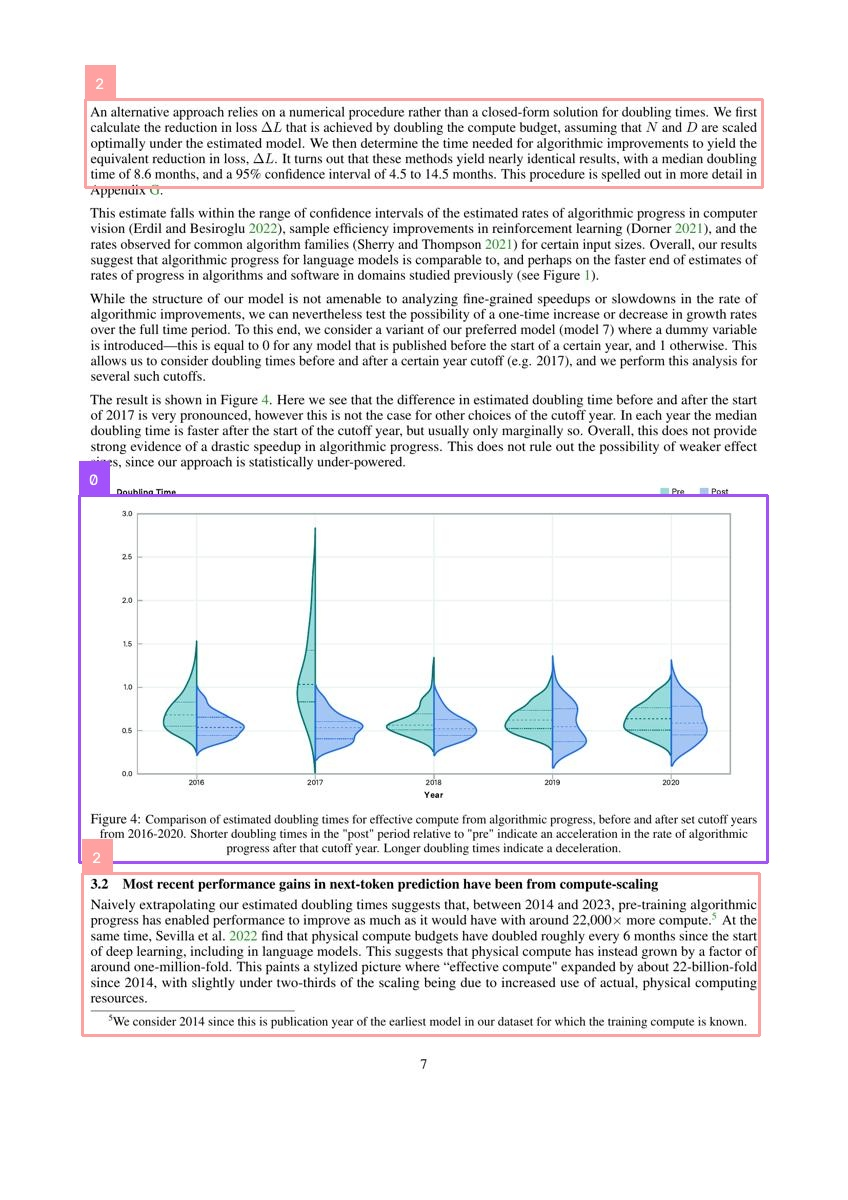

In [ ]:
import os
import random
import cv2
import supervision as sv
import IPython
from ultralytics import YOLO

# Load the custom model
model_loaded = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Assuming 'dataset' is defined earlier with a 'location' attribute
# If not, replace this with the actual path to your test images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image_path = os.path.join(test_set_loc, img_name)
    image = cv2.imread(image_path)

    # Perform inference (note: method changed from .infer() to .predict())
    results = model_loaded(image, conf=0.4)[0]  # Confidence threshold set to 0.4

    # Convert results to Supervision Detections
    detections = sv.Detections(
        xyxy=results.boxes.xyxy.cpu().numpy(),
        confidence=results.boxes.conf.cpu().numpy(),
        class_id=results.boxes.cls.cpu().numpy().astype(int)
    )

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, buffer = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=buffer)
    IPython.display.display(i)


0: 640x512 1 figure, 1 text, 15.0ms
Speed: 2.9ms preprocess, 15.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 512)


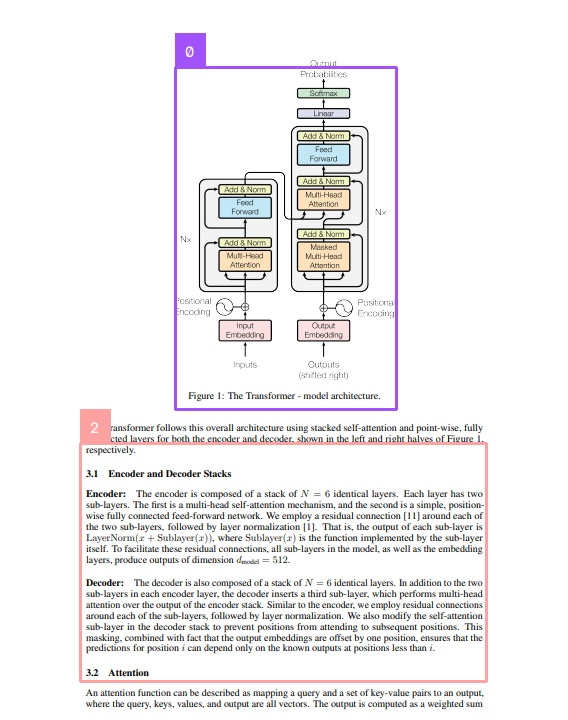

In [ ]:
import cv2
import supervision as sv
import IPython
from ultralytics import YOLO

# Load the custom model
model_loaded = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Path to the single image
image_path = "/content/Screenshot 2026-09-20 073437.png"

# Load image
image = cv2.imread(image_path)
assert image is not None, f"Could not read image at {image_path}"

# Perform inference
results = model_loaded(image, conf=0.4)[0]

# Convert results to Supervision Detections
detections = sv.Detections(
    xyxy=results.boxes.xyxy.cpu().numpy(),
    confidence=results.boxes.conf.cpu().numpy(),
    class_id=results.boxes.cls.cpu().numpy().astype(int)
)

# Annotate boxes and labels
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
annotated_image = box_annotator.annotate(scene=image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

# Display annotated image
_, buffer = cv2.imencode('.jpg', annotated_image)
IPython.display.display(IPython.display.Image(data=buffer))